# 01 — Association Analysis
Reconstructions, t-SNE, RDM, and interpolation analysis using the `neuromorph` package.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Set working directory to project root using package location
import neuromorph
os.chdir(os.path.dirname(os.path.dirname(neuromorph.__file__)))
print(f"Working directory: {os.getcwd()}")

import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision

from neuromorph.configs import ExperimentConfig
from neuromorph.training import set_global_seed, AutoencoderTrainer
from neuromorph.data import get_mnist_dataloaders, add_noise, generate_context
from neuromorph.analysis import capture_activations, compute_joint_tsne, compute_distance_change, compute_balanced_rdm
from neuromorph.visualization import apply_neuromorph_style, save_figure, show_image, save_high_res_image, plot_average_images
from neuromorph.visualization import plot_tsne_flow_field, plot_rdm_comparison

apply_neuromorph_style()

config = ExperimentConfig()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

set_global_seed(config.training.seed)

Working directory: C:\Users\matteucc\Desktop\Playground\NeuroMorph
Device: cuda


## Load Data and Pretrained Models

In [2]:
train_dl, test_dl = get_mnist_dataloaders(batch_size=config.training.batch_size)

trainer = AutoencoderTrainer(config, device=device)
baseline_ae, association_ae = trainer.train(train_dl, retrain=False)

Loaded pretrained baseline and association models.


## Reconstructions

Saved: ./output\01_original.png


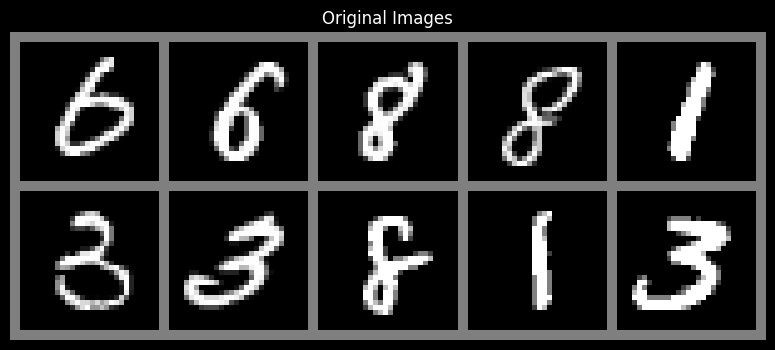

Saved: ./output\01_noisy_input.png


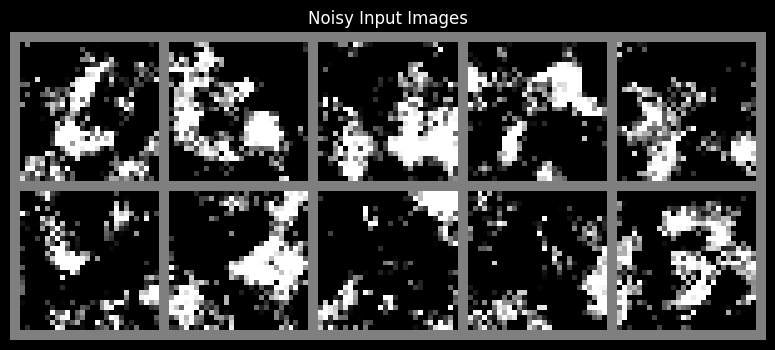

Saved: ./output\01_recon_no_context.png


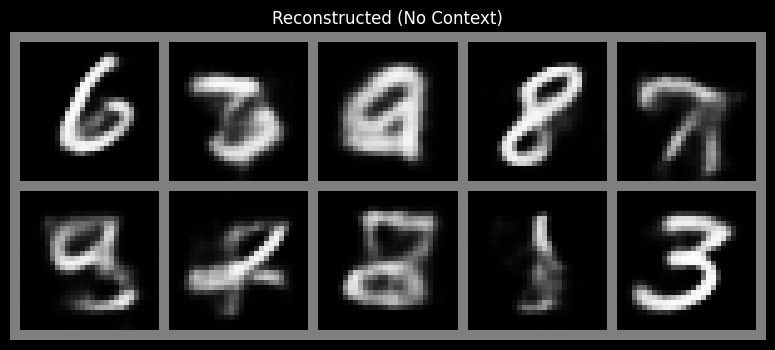

Saved: ./output\01_recon_with_context.png


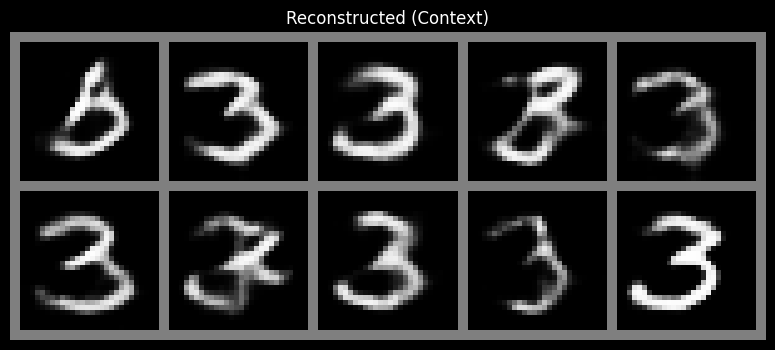

In [3]:
%matplotlib inline
mc = config.model
nc = config.noise
cc = config.context

association_ae.eval()

images_test, labels_test = next(iter(test_dl))
images_test = images_test.to(device)

noisy_images_test = add_noise(images_test, noise_level=1.0,
                              correlated=nc.correlated, uncorrelated=nc.uncorrelated,
                              kernel_size=nc.kernel_size, sigma=nc.sigma)

context_test = generate_context(noisy_images_test.size(0), signal_level=cc.eval_signal_level,
                                noise_level=cc.noise_level, category_id=cc.context_id,
                                context_dim=mc.context_dim, device=device)
no_context_test = generate_context(noisy_images_test.size(0), signal_level=None,
                                   noise_level=cc.noise_level, category_id=cc.context_id,
                                   context_dim=mc.context_dim, device=device)

recon_ctx = association_ae(noisy_images_test, context_test).cpu()
recon_no_ctx = association_ae(noisy_images_test, no_context_test).cpu()

for tensor, title, fname in [
    (images_test[:10], "Original Images", "01_original"),
    (noisy_images_test[:10], "Noisy Input Images", "01_noisy_input"),
    (recon_no_ctx[:10], "Reconstructed (No Context)", "01_recon_no_context"),
    (recon_ctx[:10], "Reconstructed (Context)", "01_recon_with_context"),
]:
    fig, ax = plt.subplots(figsize=(10, 4))
    img = torchvision.utils.make_grid(tensor.cpu(), nrow=5)
    img = 0.5 * (img + 1)
    ax.imshow(np.transpose(img.clamp(0, 1).numpy(), (1, 2, 0)), cmap='gray')
    ax.set_title(title)
    ax.axis('off')
    save_figure(fig, fname)
    plt.show()

## Average Images Per Category

Saved: ./output\01_average_images.png


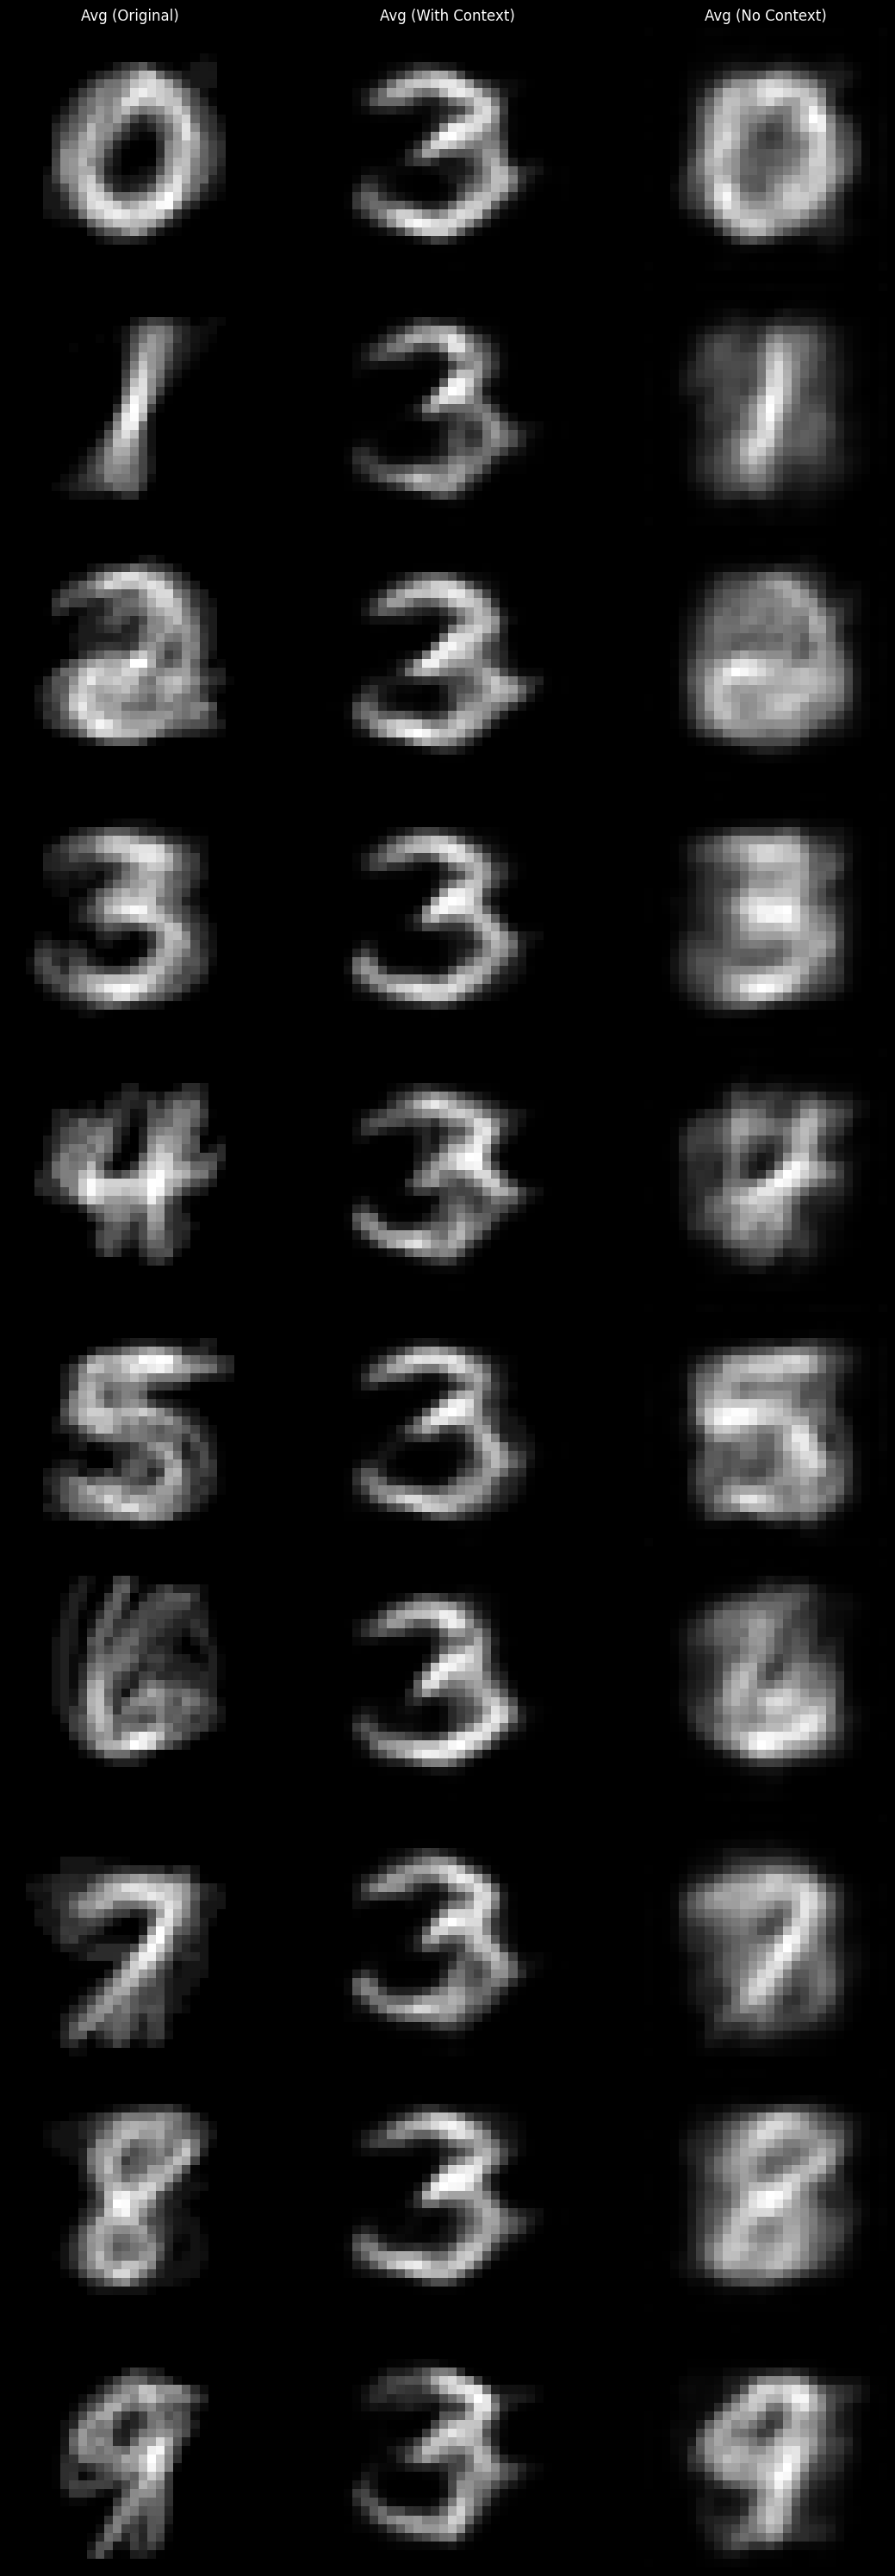

In [4]:
fig = plot_average_images(images_test, labels_test, recon_ctx, recon_no_ctx)
save_figure(fig, "01_average_images")
plt.show()

## t-SNE Analysis

Saved: ./output\01_tsne_analysis.png


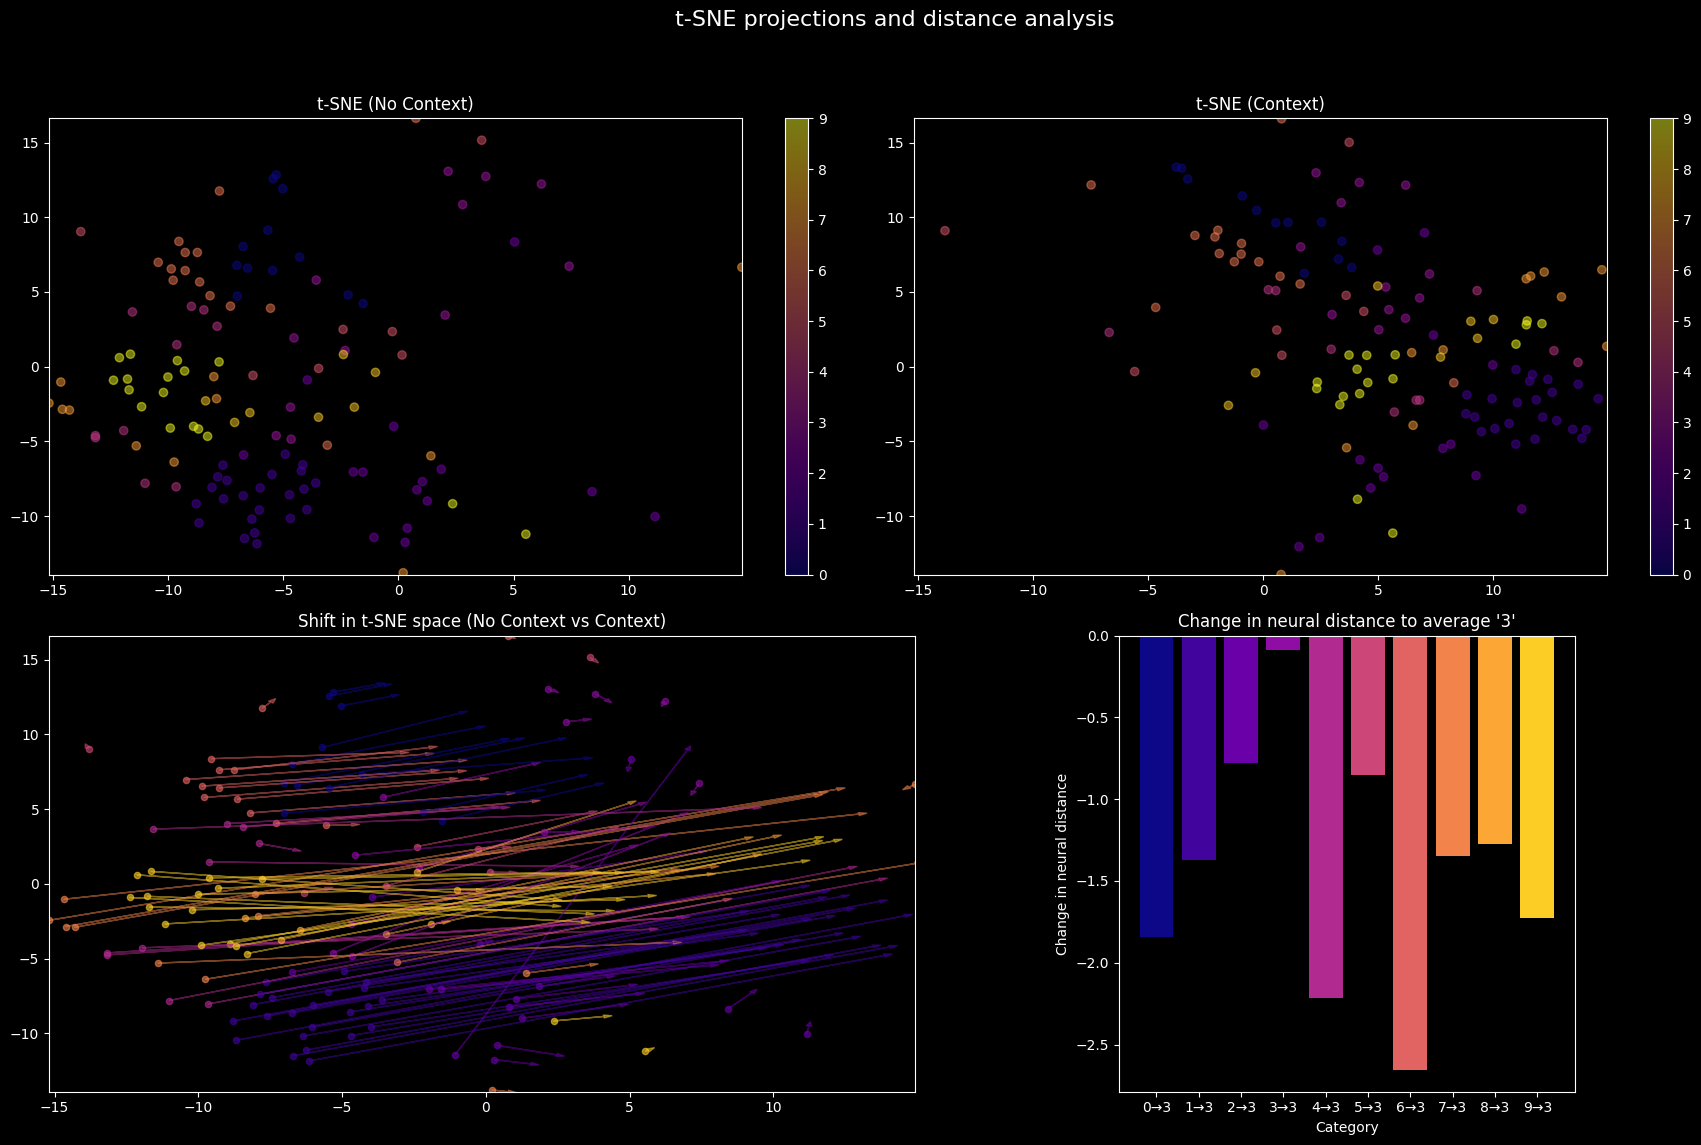

In [5]:
images_test, labels_test = next(iter(test_dl))
images_test = images_test.to(device)
labels_np = labels_test.cpu().numpy()

noisy_images_test = add_noise(images_test, noise_level=nc.training_noise_level,
                              correlated=nc.correlated, uncorrelated=nc.uncorrelated,
                              kernel_size=nc.kernel_size, sigma=nc.sigma)

context_test = generate_context(noisy_images_test.size(0), signal_level=cc.eval_signal_level,
                                noise_level=cc.noise_level, category_id=cc.context_id,
                                context_dim=mc.context_dim, device=device)
no_context_test = generate_context(noisy_images_test.size(0), signal_level=None,
                                   noise_level=cc.noise_level, category_id=cc.context_id,
                                   context_dim=mc.context_dim, device=device)

act_no_ctx = capture_activations(association_ae, noisy_images_test, no_context_test)
act_ctx = capture_activations(association_ae, noisy_images_test, context_test)

tsne_no_ctx, tsne_ctx = compute_joint_tsne(act_no_ctx, act_ctx, labels_np)
distance_diffs = compute_distance_change(act_no_ctx, act_ctx, labels_np, target_digit=cc.target_digit)

# Plot t-SNE panels
from neuromorph.visualization.style import CMAP

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("t-SNE projections and distance analysis", fontsize=16)

combined = np.concatenate([tsne_no_ctx, tsne_ctx], axis=0)
x_min, x_max = combined[:, 0].min(), combined[:, 0].max()
y_min, y_max = combined[:, 1].min(), combined[:, 1].max()

for ax_idx, (tsne_data, title) in enumerate([(tsne_no_ctx, 'No Context'), (tsne_ctx, 'Context')]):
    ax = axs[0, ax_idx]
    ax.set_title(f't-SNE ({title})')
    scatter = ax.scatter(tsne_data[:, 0], tsne_data[:, 1], c=labels_np, cmap=CMAP, alpha=0.5)
    ax.figure.colorbar(scatter, ax=ax, ticks=range(10))
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plot_tsne_flow_field(tsne_no_ctx, tsne_ctx, labels_np, ax=axs[1, 0])

axs[1, 1].bar(range(10), distance_diffs, color=plt.cm.plasma(np.arange(10) / 10))
axs[1, 1].set_xticks(range(10))
axs[1, 1].set_xticklabels([f"{i}→{cc.target_digit}" for i in range(10)])
axs[1, 1].set_title(f"Change in neural distance to average '{cc.target_digit}'")
axs[1, 1].set_xlabel("Category")
axs[1, 1].set_ylabel("Change in neural distance")
axs[1, 1].set_box_aspect(1)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
save_figure(fig, "01_tsne_analysis")
plt.show()

## RDM Analysis

Saved: ./output\01_rdm_analysis.png


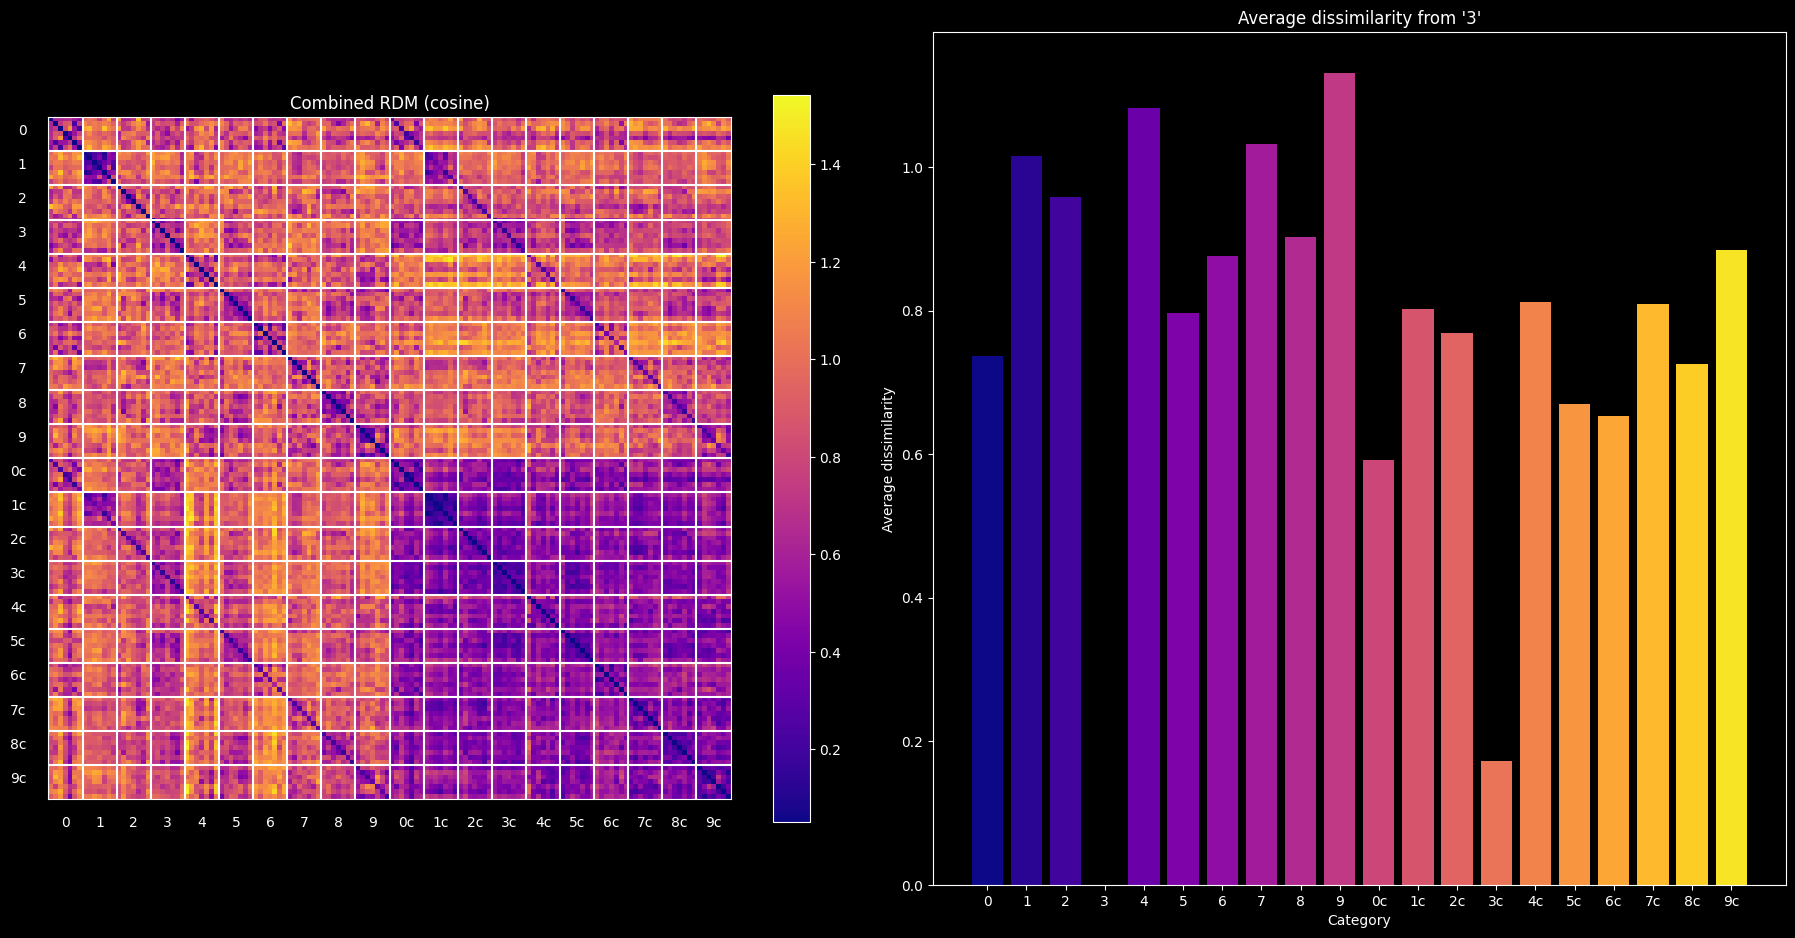

In [6]:
rdm, rdm_labels, samples_per_class = compute_balanced_rdm(act_no_ctx, act_ctx, labels_np)

fig, (ax_rdm, ax_bar) = plt.subplots(1, 2, figsize=(18, 10))
plot_rdm_comparison(rdm, rdm_labels, samples_per_class, target_digit=cc.target_digit,
                    ax_rdm=ax_rdm, ax_bar=ax_bar)
plt.tight_layout()
save_figure(fig, "01_rdm_analysis")
plt.show()